In [ ]:
from google.colab import files

uploaded = files.upload()


In [4]:
import pandas as pd

df = pd.read_csv('/content/PS_20174392719_1491204439457_log 4.56.52\u202fPM.csv')

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [5]:
import os

print(os.listdir('/content'))

['.config', 'PS_20174392719_1491204439457_log 4.56.52\u202fPM.csv', 'sample_data']


In [6]:
pd.read_csv('/content/PS_20174392719_1491204439457_log 4.56.52\u202fPM.csv')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [7]:
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [8]:
# Create new column
df['risk_score'] = 0

In [9]:
rule1 = (df['amount'] > 200000) & (df['type'] == 'TRANSFER')

df.loc[rule1, 'risk_score'] += 50

In [10]:
rule2 = (df['newbalanceOrig'] == 0)

df.loc[rule2, 'risk_score'] += 30

In [11]:
rule3 = (df['type'] == 'CASH_OUT') & (df['amount'] > 100000)

df.loc[rule3, 'risk_score'] += 20

In [16]:
df['predicted_fraud'] = df['risk_score'] >= 50

print("Fraud Detection Completed")

Fraud Detection Completed


In [17]:
fraud_cases = df[df['predicted_fraud'] == True]

print(fraud_cases[['amount', 'type', 'risk_score']].head(10))

        amount      type  risk_score
15   229133.94  CASH_OUT          50
19   215310.30  TRANSFER          80
24   311685.89  TRANSFER          80
42   110414.71  CASH_OUT          50
82   224606.64  TRANSFER          80
84   379856.23  TRANSFER          80
85  1505626.01  TRANSFER          80
86   554026.99  TRANSFER          80
88   761507.39  TRANSFER          80
89  1429051.47  TRANSFER          80


In [18]:
print("Total Suspicious Transactions:")
print(len(fraud_cases))

Total Suspicious Transactions:
1788513


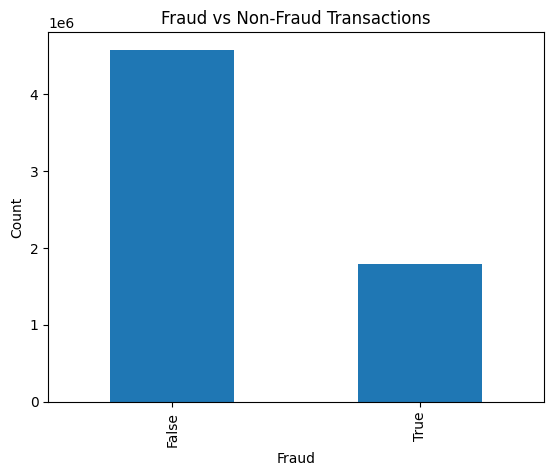

In [19]:
import matplotlib.pyplot as plt

fraud_counts = df['predicted_fraud'].value_counts()

fraud_counts.plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

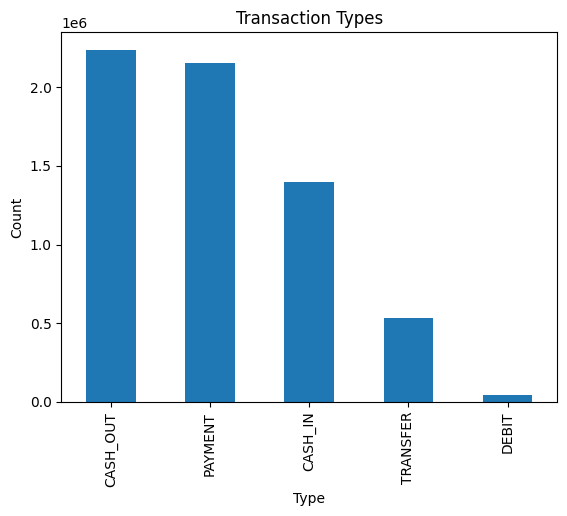

In [20]:
df['type'].value_counts().plot(kind='bar')

plt.title("Transaction Types")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

In [21]:
fraud_cases.to_csv('suspicious_transactions.csv', index=False)

print("CSV Exported Successfully")

CSV Exported Successfully
